In [10]:
# Import pandas for data manipulation and time-series analysis
import pandas as pd
# Import numpy for numerical and vectorized calculations
import numpy as np
# Import yfinance to pull historical market data from Yahoo Finance
import yfinance as yf
# Import statsmodels to run the Ordinary Least Squares (OLS) CAPM regression
import statsmodels.api as sm
# Import datetime to handle date arithmetic
from datetime import datetime
# Import dateutil.relativedelta to easily subtract exactly 2 years from today
from dateutil.relativedelta import relativedelta

In [11]:
# Define today's date dynamically as the end of our entire dataset
end_date = datetime.today()
# Calculate the cutoff date separating the last 2 years from the prior history
split_date = end_date - relativedelta(years=2)
# Define a target start date 10 years ago (8 years prior + 2 recent years)
# Note: yfinance will automatically truncate this to June 12, 2019 for CRWD
start_date = end_date - relativedelta(years=10)

# Define the strategy asset (CrowdStrike)
asset_ticker = "MELI"
# Define the market benchmark (S&P 500 ETF)
market_ticker = "SPY"
# Define the risk-free rate proxy (10-Year Treasury Yield index)
rf_ticker = "^TNX"

In [12]:
# Download historical market data

# Download adjusted closing prices for the asset and market
price_data = yf.download(
    [asset_ticker, market_ticker],
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

# Download the 10-year US Treasury yield
rf_data = yf.download(
    rf_ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False
)["Close"]

# Calculate daily returns
returns = price_data.pct_change()

# Convert Treasury yield from percentage to decimal
rf_data = rf_data / 100

# Combine asset/market returns and risk-free rate
data = returns.copy()
data["Risk_Free"] = rf_data

# Remove all rows containing NaN values
data = data.dropna()

# Display the cleaned data
print("Cleaned data:")
display(data.head())

print("\nNumber of observations:", len(data))
print("\nRemaining NaN values:")
print(data.isna().sum())


[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed

Cleaned data:


Ticker,MELI,SPY,Risk_Free
Date,,,
2016-09-13,-0.014481,-0.014376,0.01734
2016-09-14,-0.027919,-0.000375,0.01689
2016-09-15,0.015175,0.009993,0.01703
2016-09-16,0.014833,-0.003866,0.01701
2016-09-19,0.009650,0.000188,0.01696



Number of observations: 2511

Remaining NaN values:
Ticker
MELI         0
SPY          0
Risk_Free    0
dtype: int64


In [13]:
# Create the main dataframe for the CAPM/SMA analysis

df = pd.DataFrame()

# Asset price
df['Asset_Price'] = price_data[asset_ticker]

# Market price
df['Market_Price'] = price_data[market_ticker]

# Calculate daily returns
df['Asset_Return'] = df['Asset_Price'].pct_change()
df['Market_Return'] = df['Market_Price'].pct_change()

# Add the risk-free rate
df['Risk_Free'] = rf_data

# Remove rows containing missing values
df = df.dropna()

# Display the first few rows
display(df.head())

# Check for remaining NaN values
print("Remaining NaN values:")
print(df.isna().sum())


,Asset_Price,Market_Price,Asset_Return,Market_Return,Risk_Free
Date,,,,,
2016-09-13,176.220551,181.632126,-0.014481,-0.014376,0.01734
2016-09-14,171.300644,181.563950,-0.027919,-0.000375,0.01689
2016-09-15,173.900055,183.378357,0.015175,0.009993,0.01703
2016-09-16,176.479492,182.669495,0.014833,-0.003866,0.01701
2016-09-19,178.182571,182.703751,0.009650,0.000188,0.01696


Remaining NaN values:
Asset_Price      0
Market_Price     0
Asset_Return     0
Market_Return    0
Risk_Free        0
dtype: int64


In [14]:
# ============================================================
# CREATE STRATEGIES FOR CAPM COMPARISON
# ============================================================

# ------------------------------------------------------------
# Strategy 1: Buy & Hold
# ------------------------------------------------------------

df['BuyHold_Return'] = df['Asset_Return']


# ------------------------------------------------------------
# Strategy 2: 50-Day SMA
# ------------------------------------------------------------

df['SMA_50'] = (
    df['Asset_Price']
    .rolling(window=50)
    .mean()
    .shift(1)
)

df['Signal_50'] = np.where(
    df['Asset_Price'].shift(1) > df['SMA_50'],
    1,
    0
)

df['SMA50_Return'] = (
    df['Signal_50'] * df['Asset_Return']
)


# ------------------------------------------------------------
# Strategy 3: 200-Day SMA
# ------------------------------------------------------------

df['SMA_200'] = (
    df['Asset_Price']
    .rolling(window=200)
    .mean()
    .shift(1)
)

df['Signal_200'] = np.where(
    df['Asset_Price'].shift(1) > df['SMA_200'],
    1,
    0
)

df['SMA200_Return'] = (
    df['Signal_200'] * df['Asset_Return']
)


# ------------------------------------------------------------
# Strategy 4: 50/200 SMA Crossover
# ------------------------------------------------------------

df['Crossover_Signal'] = np.where(
    df['SMA_50'] > df['SMA_200'],
    1,
    0
)

df['Crossover_Return'] = (
    df['Crossover_Signal'] * df['Asset_Return']
)


# Remove rows where the 200-day SMA is not available
df = df.dropna(
    subset=[
        'SMA_200',
        'SMA50_Return',
        'SMA200_Return',
        'Crossover_Return'
    ]
)

print("Strategies successfully created.")
display(
    df[
        [
            'Asset_Price',
            'Asset_Return',
            'BuyHold_Return',
            'SMA50_Return',
            'SMA200_Return',
            'Crossover_Return'
        ]
    ].head()
)


Strategies successfully created.


,Asset_Price,Asset_Return,BuyHold_Return,SMA50_Return,SMA200_Return,Crossover_Return
Date,,,,,,
2017-06-30,250.621384,-0.006140,-0.006140,-0.0,-0.006140,-0.006140
2017-07-03,250.421570,-0.000797,-0.000797,-0.0,-0.000797,-0.000797
2017-07-05,248.723312,-0.006782,-0.006782,-0.0,-0.006782,-0.006782
2017-07-06,250.841141,0.008515,0.008515,0.0,0.008515,0.008515
2017-07-07,255.336502,0.017921,0.017921,0.0,0.017921,0.017921


In [15]:
# ============================================================
# CALCULATE EXCESS RETURNS
# ============================================================

df['BuyHold_Excess'] = (
    df['BuyHold_Return'] - df['Risk_Free']
)

df['SMA50_Excess'] = (
    df['SMA50_Return'] - df['Risk_Free']
)

df['SMA200_Excess'] = (
    df['SMA200_Return'] - df['Risk_Free']
)

df['Crossover_Excess'] = (
    df['Crossover_Return'] - df['Risk_Free']
)

df['Market_Excess'] = (
    df['Market_Return'] - df['Risk_Free']
)

print("Excess returns calculated.")


Excess returns calculated.


In [16]:
# ============================================================
# FINAL CAPM COMPARISON TABLE
# ============================================================

def calculate_capm_stats(data, excess_return_column):

    # Select the strategy and market excess returns
    regression_data = data[
        [excess_return_column, 'Market_Excess']
    ].dropna()

    # Independent variable: Market Excess Return
    X = regression_data['Market_Excess']

    # Add intercept for Alpha
    X = sm.add_constant(X)

    # Dependent variable: Strategy Excess Return
    y = regression_data[excess_return_column]

    # Run OLS regression
    model = sm.OLS(y, X).fit()

    # Extract CAPM statistics
    alpha_daily = model.params['const']
    alpha_annual = alpha_daily * 252
    beta = model.params['Market_Excess']
    alpha_pvalue = model.pvalues['const']
    r_squared = model.rsquared

    return {
        'Annualized Alpha': alpha_annual,
        'Alpha P-Value': alpha_pvalue,
        'Beta': beta,
        'R-Squared': r_squared,
        'Observations': len(regression_data)
    }


# ------------------------------------------------------------
# Calculate CAPM statistics for each strategy
# ------------------------------------------------------------

strategies = {
    'Buy & Hold': 'BuyHold_Excess',
    '50-Day SMA': 'SMA50_Excess',
    '200-Day SMA': 'SMA200_Excess',
    '50/200 SMA Crossover': 'Crossover_Excess'
}


# Create results list
results = []

for strategy_name, return_column in strategies.items():

    stats = calculate_capm_stats(
        df,
        return_column
    )

    stats['Strategy'] = strategy_name

    results.append(stats)


# Convert results into a dataframe
capm_table = pd.DataFrame(results)


# Put Strategy as the first column
capm_table = capm_table[
    [
        'Strategy',
        'Annualized Alpha',
        'Alpha P-Value',
        'Beta',
        'R-Squared',
        'Observations'
    ]
]


# Format the table
capm_table['Annualized Alpha'] = (
    capm_table['Annualized Alpha'] * 100
)

capm_table['Annualized Alpha'] = (
    capm_table['Annualized Alpha'].round(2)
)

capm_table['Alpha P-Value'] = (
    capm_table['Alpha P-Value'].round(4)
)

capm_table['Beta'] = (
    capm_table['Beta'].round(4)
)

capm_table['R-Squared'] = (
    capm_table['R-Squared'].round(4)
)


# Display final table
print("============================================================")
print("FINAL CAPM STRATEGY COMPARISON")
print("============================================================")

display(capm_table)


FINAL CAPM STRATEGY COMPARISON


,Strategy,Annualized Alpha,Alpha P-Value,Beta,R-Squared,Observations
0,Buy & Hold,172.42,0.0000,1.2125,0.3759,2311
1,50-Day SMA,-149.24,0.0000,0.7852,0.2824,2311
2,200-Day SMA,-119.87,0.0000,0.8380,0.2895,2311
3,50/200 SMA Crossover,-64.12,0.0035,0.9059,0.3450,2311


FINAL CAPM STRATEGY COMPARISON
Asset: MELI
Market: SPY
Split date: 2024-09-10 00:00:00


,Period,Strategy,Annualized Alpha (%),Alpha P-Value,Beta,R-Squared,Observations
0,Prior Period,Buy & Hold,204.19,0.0000,1.2809,0.3755,1809
1,Prior Period,50-Day SMA,-127.53,0.0000,0.7711,0.2561,1809
2,Prior Period,200-Day SMA,-125.47,0.0000,0.7942,0.2600,1809
3,Prior Period,50/200 SMA Crossover,-76.58,0.0005,0.8723,0.3307,1809
4,Recent 2 Years,Buy & Hold,-176.24,0.1024,0.8481,0.1306,502
5,Recent 2 Years,50-Day SMA,-816.88,0.0000,0.2604,0.0245,502
6,Recent 2 Years,200-Day SMA,-669.05,0.0000,0.4063,0.0580,502
7,Recent 2 Years,50/200 SMA Crossover,-441.03,0.0000,0.5990,0.1128,502



Alpha Comparison:


Period,Prior Period,Recent 2 Years
Strategy,,
200-Day SMA,-125.47,-669.05
50-Day SMA,-127.53,-816.88
50/200 SMA Crossover,-76.58,-441.03
Buy & Hold,204.19,-176.24


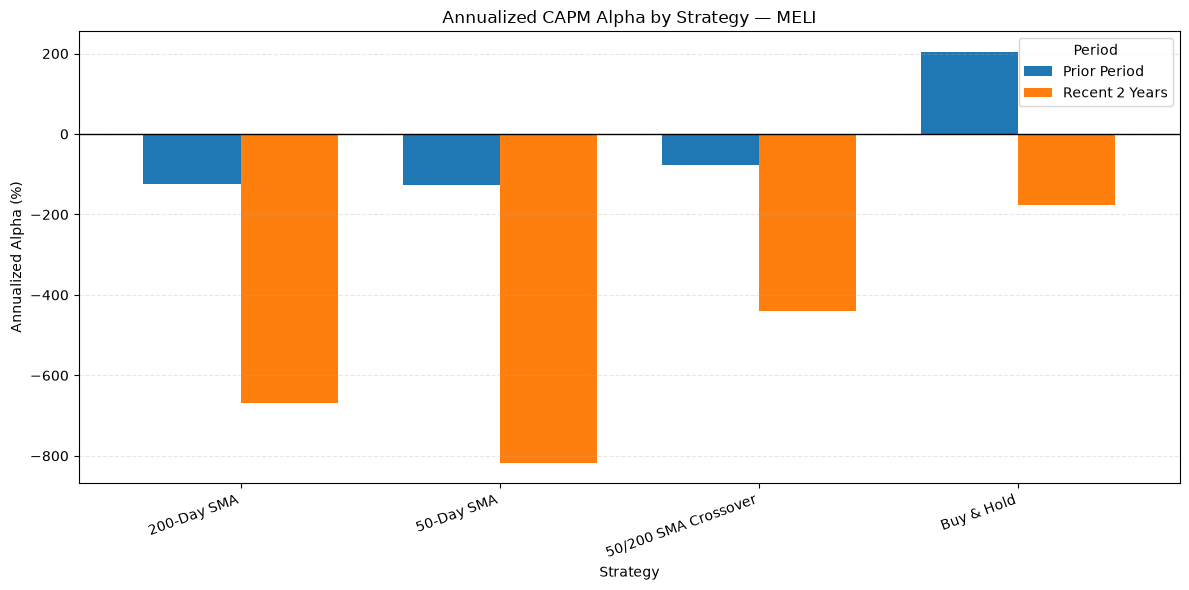

In [17]:
# ============================================================
# FINAL CAPM ANALYSIS + ALPHA VISUALISATION
# ============================================================

# ------------------------------------------------------------
# 1. Make sure the strategy excess returns exist
# ------------------------------------------------------------

# Buy & Hold
df['BuyHold_Return'] = df['Asset_Return']
df['BuyHold_Excess'] = df['BuyHold_Return'] - df['Risk_Free']


# 50-Day SMA
df['SMA_50'] = (
    df['Asset_Price']
    .rolling(window=50)
    .mean()
    .shift(1)
)

df['Signal_50'] = np.where(
    df['Asset_Price'].shift(1) > df['SMA_50'],
    1,
    0
)

df['SMA50_Return'] = (
    df['Signal_50'] * df['Asset_Return']
)

df['SMA50_Excess'] = (
    df['SMA50_Return'] - df['Risk_Free']
)


# 200-Day SMA
df['SMA_200'] = (
    df['Asset_Price']
    .rolling(window=200)
    .mean()
    .shift(1)
)

df['Signal_200'] = np.where(
    df['Asset_Price'].shift(1) > df['SMA_200'],
    1,
    0
)

df['SMA200_Return'] = (
    df['Signal_200'] * df['Asset_Return']
)

df['SMA200_Excess'] = (
    df['SMA200_Return'] - df['Risk_Free']
)


# 50/200 SMA Crossover
df['Crossover_Signal'] = np.where(
    df['SMA_50'] > df['SMA_200'],
    1,
    0
)

df['Crossover_Return'] = (
    df['Crossover_Signal'] * df['Asset_Return']
)

df['Crossover_Excess'] = (
    df['Crossover_Return'] - df['Risk_Free']
)


# Market excess return
df['Market_Excess'] = (
    df['Market_Return'] - df['Risk_Free']
)


# ------------------------------------------------------------
# 2. Remove missing values
# ------------------------------------------------------------

df = df.dropna(
    subset=[
        'Market_Excess',
        'BuyHold_Excess',
        'SMA50_Excess',
        'SMA200_Excess',
        'Crossover_Excess'
    ]
)


# ------------------------------------------------------------
# 3. Create the two analysis periods
# ------------------------------------------------------------

# Two years before the most recent observation
split_date = df.index.max() - pd.DateOffset(years=2)

# Prior period
df_prior = df[df.index < split_date].copy()

# Recent 2-year period
df_recent = df[df.index >= split_date].copy()


# ------------------------------------------------------------
# 4. CAPM regression function
# ------------------------------------------------------------

def calculate_capm(data, strategy_column):

    regression_data = data[
        [strategy_column, 'Market_Excess']
    ].dropna()

    X = regression_data['Market_Excess']
    X = sm.add_constant(X)

    y = regression_data[strategy_column]

    model = sm.OLS(y, X).fit()

    # Daily Alpha
    alpha_daily = model.params['const']

    # Annualized Alpha
    alpha_annual = alpha_daily * 252

    # Beta
    beta = model.params['Market_Excess']

    # Alpha p-value
    alpha_pvalue = model.pvalues['const']

    # R-squared
    r_squared = model.rsquared

    return {
        'Annualized Alpha (%)': alpha_annual * 100,
        'Alpha P-Value': alpha_pvalue,
        'Beta': beta,
        'R-Squared': r_squared,
        'Observations': len(regression_data)
    }


# ------------------------------------------------------------
# 5. Define strategies
# ------------------------------------------------------------

strategies = {
    'Buy & Hold': 'BuyHold_Excess',
    '50-Day SMA': 'SMA50_Excess',
    '200-Day SMA': 'SMA200_Excess',
    '50/200 SMA Crossover': 'Crossover_Excess'
}


# ------------------------------------------------------------
# 6. Calculate CAPM results for both periods
# ------------------------------------------------------------

results = []

for period_name, period_data in [
    ('Prior Period', df_prior),
    ('Recent 2 Years', df_recent)
]:

    for strategy_name, strategy_column in strategies.items():

        stats = calculate_capm(
            period_data,
            strategy_column
        )

        results.append({
            'Period': period_name,
            'Strategy': strategy_name,
            **stats
        })


# ------------------------------------------------------------
# 7. Create final results table
# ------------------------------------------------------------

final_capm_table = pd.DataFrame(results)

# Round results
final_capm_table['Annualized Alpha (%)'] = (
    final_capm_table['Annualized Alpha (%)'].round(2)
)

final_capm_table['Alpha P-Value'] = (
    final_capm_table['Alpha P-Value'].round(4)
)

final_capm_table['Beta'] = (
    final_capm_table['Beta'].round(4)
)

final_capm_table['R-Squared'] = (
    final_capm_table['R-Squared'].round(4)
)


# ------------------------------------------------------------
# 8. Display final table
# ------------------------------------------------------------

print("=" * 75)
print("FINAL CAPM STRATEGY COMPARISON")
print("=" * 75)

print(f"Asset: {asset_ticker}")
print(f"Market: {market_ticker}")
print(f"Split date: {split_date}")

display(final_capm_table)


# ------------------------------------------------------------
# 9. Create Alpha comparison table for plotting
# ------------------------------------------------------------

alpha_plot_data = final_capm_table.pivot(
    index='Strategy',
    columns='Period',
    values='Annualized Alpha (%)'
)

print("\nAlpha Comparison:")
display(alpha_plot_data)


# ------------------------------------------------------------
# 10. Visualise Alpha
# ------------------------------------------------------------

import matplotlib.pyplot as plt

ax = alpha_plot_data.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.75
)

plt.axhline(
    y=0,
    color='black',
    linewidth=1
)

plt.title(
    f'Annualized CAPM Alpha by Strategy — {asset_ticker}'
)

plt.xlabel('Strategy')
plt.ylabel('Annualized Alpha (%)')

plt.xticks(
    rotation=20,
    ha='right'
)

plt.legend(
    title='Period'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()


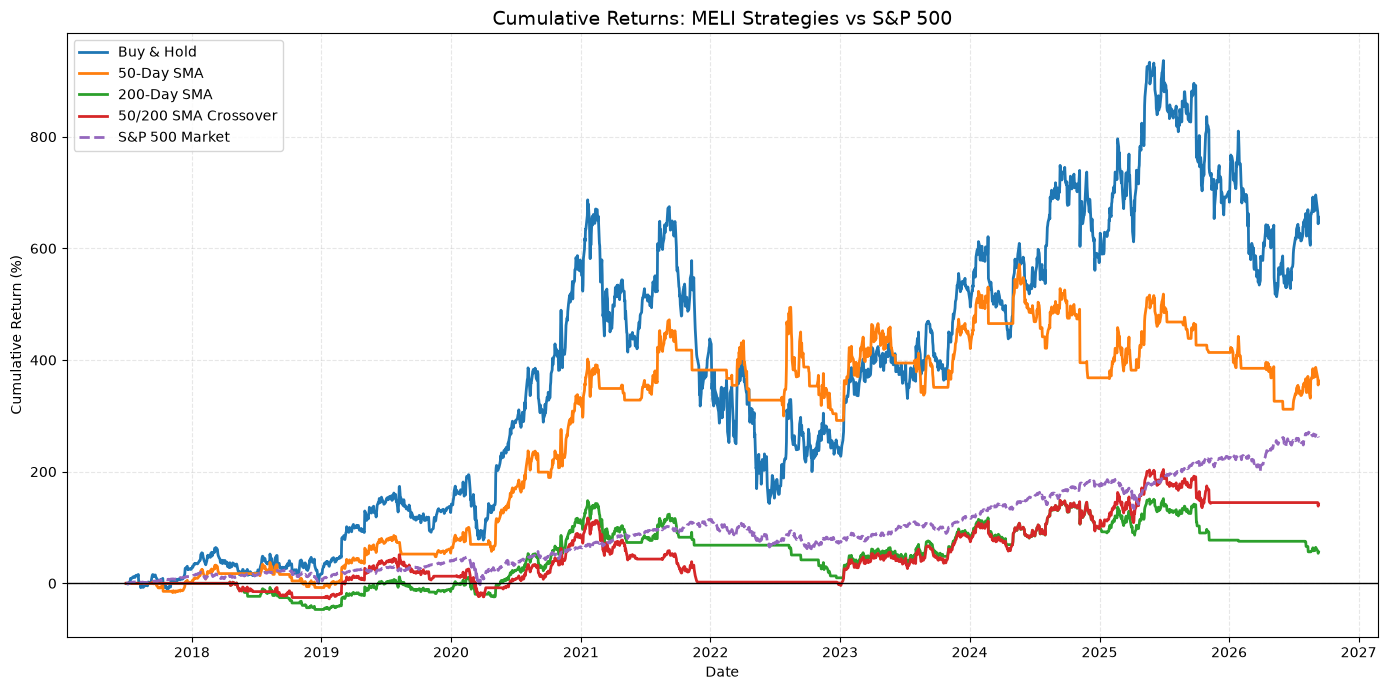

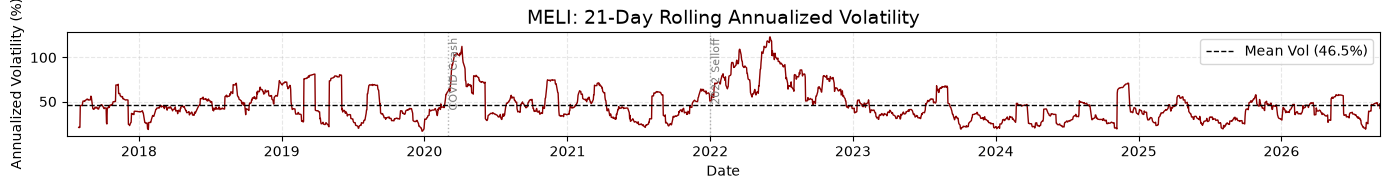

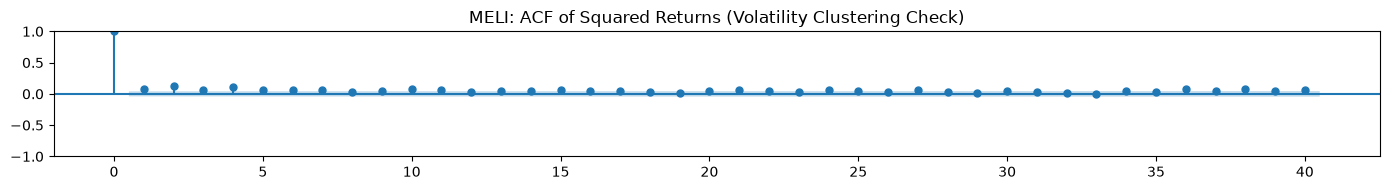

Ljung-Box test on squared returns:


,lb_stat,lb_pvalue
10,133.435831,9.288804e-24
20,189.720774,1.200698e-29



Low p-values (near 0) -> reject the null of no autocorrelation
-> statistical confirmation of volatility clustering (ARCH effects).


In [28]:
# ============================================================
# CUMULATIVE RETURNS: ALL STRATEGIES VS MARKET
# ============================================================

import matplotlib.pyplot as plt

# Calculate cumulative returns for each strategy
cumulative_buyhold = (
    1 + df['BuyHold_Return']
).cumprod() - 1

cumulative_sma50 = (
    1 + df['SMA50_Return']
).cumprod() - 1

cumulative_sma200 = (
    1 + df['SMA200_Return']
).cumprod() - 1

cumulative_crossover = (
    1 + df['Crossover_Return']
).cumprod() - 1

# Calculate cumulative market return
cumulative_market = (
    1 + df['Market_Return']
).cumprod() - 1


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    cumulative_buyhold.index,
    cumulative_buyhold * 100,
    label='Buy & Hold',
    linewidth=2
)

plt.plot(
    cumulative_sma50.index,
    cumulative_sma50 * 100,
    label='50-Day SMA',
    linewidth=2
)

plt.plot(
    cumulative_sma200.index,
    cumulative_sma200 * 100,
    label='200-Day SMA',
    linewidth=2
)

plt.plot(
    cumulative_crossover.index,
    cumulative_crossover * 100,
    label='50/200 SMA Crossover',
    linewidth=2
)

plt.plot(
    cumulative_market.index,
    cumulative_market * 100,
    label='S&P 500 Market',
    linewidth=2,
    linestyle='--'
)


# Zero-return reference line
plt.axhline(
    y=0,
    color='black',
    linewidth=1
)


# Chart formatting
plt.title(
    f'Cumulative Returns: {asset_ticker} Strategies vs S&P 500',
    fontsize=14
)

plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')

plt.legend()

plt.grid(
    True,
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# VOLATILITY CLUSTERING: ROLLING REALIZED VOLATILITY
# (aligned to same date range as cumulative returns chart above)
# ============================================================

df['RollingVol_21d'] = df['Asset_Return'].rolling(window=21).std() * np.sqrt(252) * 100

plt.figure(figsize=(14, 2))

plt.plot(
    df.index,
    df['RollingVol_21d'],
    linewidth=1,
    color='darkred'
)

# Shade a rough "elevated volatility" reference band so spikes stand out
plt.axhline(
    y=df['RollingVol_21d'].mean(),
    color='black',
    linewidth=1,
    linestyle='--',
    label=f"Mean Vol ({df['RollingVol_21d'].mean():.1f}%)"
)

# Optional: mark known major market events for easy visual cross-reference
event_dates = {
    'COVID Crash': '2020-03-01',
    '2022 Selloff': '2022-01-01',
}

for label, date_str in event_dates.items():
    event_date = pd.Timestamp(date_str)
    if event_date >= df.index.min() and event_date <= df.index.max():
        plt.axvline(x=event_date, color='gray', linewidth=1, linestyle=':', alpha=0.6)
        plt.text(
            event_date, plt.ylim()[1] * 0.95, label,
            rotation=90, verticalalignment='top', fontsize=8, color='gray'
        )

plt.title(f'{asset_ticker}: 21-Day Rolling Annualized Volatility', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Annualized Volatility (%)')

# Match x-axis limits to the chart above for direct visual comparison
plt.xlim(df.index.min(), df.index.max())

plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# FORMAL TEST: AUTOCORRELATION OF SQUARED RETURNS
# (confirms volatility clustering seen in the rolling vol chart)
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

squared_returns = df['Asset_Return'] ** 2

fig, ax = plt.subplots(figsize=(14, 2))
plot_acf(squared_returns, lags=40, ax=ax)
ax.set_title(f'{asset_ticker}: ACF of Squared Returns (Volatility Clustering Check)')
plt.tight_layout()
plt.show()

# Ljung-Box test — null hypothesis is NO autocorrelation (i.e. no clustering)
lb_test = acorr_ljungbox(squared_returns, lags=[10, 20], return_df=True)
print("Ljung-Box test on squared returns:")
display(lb_test)
print("\nLow p-values (near 0) -> reject the null of no autocorrelation")
print("-> statistical confirmation of volatility clustering (ARCH effects).")


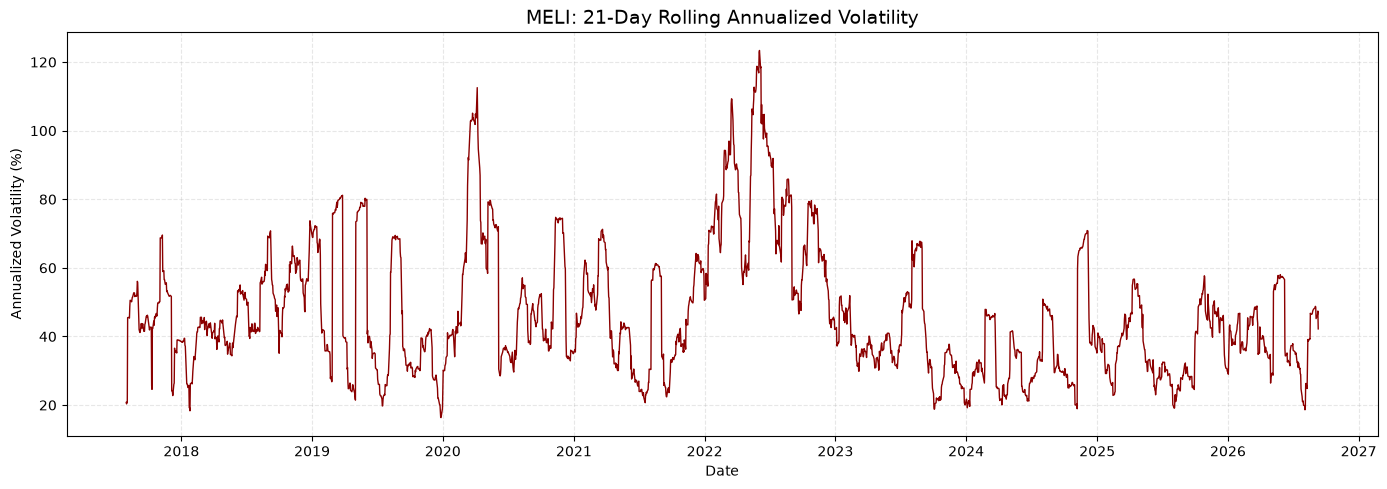

In [19]:
# ============================================================
# VOLATILITY CLUSTERING: ROLLING REALIZED VOLATILITY
# ============================================================

df['RollingVol_21d'] = df['Asset_Return'].rolling(window=21).std() * np.sqrt(252) * 100

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['RollingVol_21d'], linewidth=1, color='darkred')
plt.title(f'{asset_ticker}: 21-Day Rolling Annualized Volatility', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Annualized Volatility (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

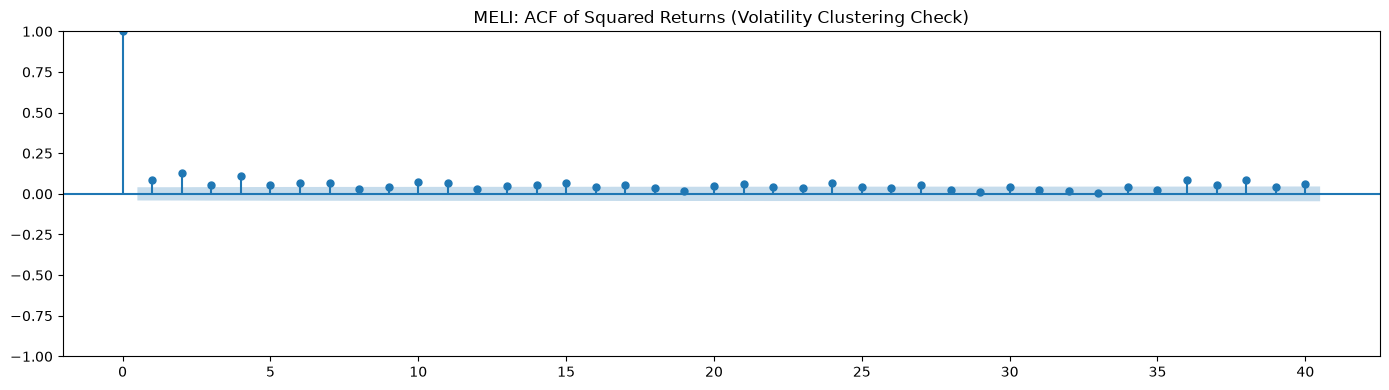

Ljung-Box test on squared returns:


,lb_stat,lb_pvalue
10,133.435831,9.288804e-24
20,189.720774,1.200698e-29



Low p-values -> reject null of no autocorrelation -> volatility clustering present.


In [20]:
# ============================================================
# FORMAL TEST: AUTOCORRELATION OF SQUARED RETURNS
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

squared_returns = df['Asset_Return'] ** 2

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(squared_returns, lags=40, ax=ax)
ax.set_title(f'{asset_ticker}: ACF of Squared Returns (Volatility Clustering Check)')
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(squared_returns, lags=[10, 20], return_df=True)
print("Ljung-Box test on squared returns:")
display(lb_test)
print("\nLow p-values -> reject null of no autocorrelation -> volatility clustering present.")

In [23]:
pip install arch

   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/934.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/934.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/934.4 kB ? eta -:--:--
   --------------------- ---------------- 524.3/934.4 kB 444.4 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/934.4 kB 444.4 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/934.4 kB 444.4 kB/s eta 0:00:01
   ------------------------------- ------ 786.4/934.4 kB 433.3 kB/s eta 0:00:01
   ---------------------------------------- 934.4/934.4 kB 467.1 kB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                 Asset_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5635.09
Distribution:      Standardized Student's t   AIC:                           11280.2
Method:                  Maximum Likelihood   BIC:                           11308.9
                                              No. Observations:                 2311
Date:                      Fri, Sep 11 2026   Df Residuals:                     2310
Time:                              18:03:19   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

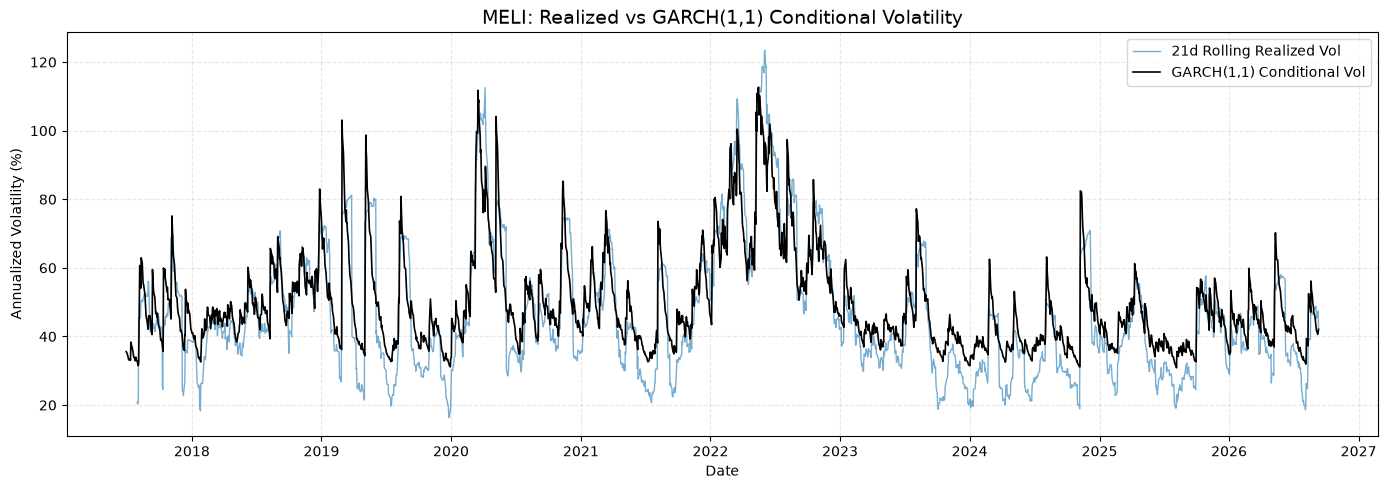

In [24]:
# ============================================================
# GARCH(1,1) MODEL FIT
# ============================================================

from arch import arch_model

returns_pct = df['Asset_Return'] * 100

garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1, dist='t')
garch_fit = garch_model.fit(disp='off')

print(garch_fit.summary())

df['GARCH_Vol'] = garch_fit.conditional_volatility * np.sqrt(252)

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['RollingVol_21d'], label='21d Rolling Realized Vol', linewidth=1, alpha=0.6)
plt.plot(df.index, df['GARCH_Vol'], label='GARCH(1,1) Conditional Vol', linewidth=1.2, color='black')
plt.title(f'{asset_ticker}: Realized vs GARCH(1,1) Conditional Volatility', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# FETCH QUARTERLY FINANCIALS (P&L) FOR THE ASSET
# ============================================================

ticker_obj = yf.Ticker(asset_ticker)

# Quarterly income statement (revenue, net income, operating income, etc.)
quarterly_financials = ticker_obj.quarterly_financials.T
quarterly_financials = quarterly_financials.sort_index()

print("Available P&L line items:")
print(quarterly_financials.columns.tolist())

display(quarterly_financials.head())

Available P&L line items:
['Tax Effect Of Unusual Items', 'Tax Rate For Calcs', 'Normalized EBITDA', 'Total Unusual Items', 'Total Unusual Items Excluding Goodwill', 'Net Income From Continuing Operation Net Minority Interest', 'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA', 'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income', 'Normalized Income', 'Net Income From Continuing And Discontinued Operation', 'Total Expenses', 'Total Operating Income As Reported', 'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS', 'Basic EPS', 'Diluted NI Availto Com Stockholders', 'Average Dilution Earnings', 'Net Income Common Stockholders', 'Otherunder Preferred Stock Dividend', 'Net Income', 'Net Income Including Noncontrolling Interests', 'Net Income Continuous Operations', 'Earnings From Equity Interest Net Of Tax', 'Tax Provision', 'Pretax Income', 'Other Income Expense', 'Gain On Sale Of Security', 'Net Non Operating Interest Income Expense', 'Interes

,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Total Unusual Items,Total Unusual Items Excluding Goodwill,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,...,Provision For Doubtful Accounts,Research And Development,Selling General And Administration,Selling And Marketing Expense,General And Administrative Expense,Other Gand A,Gross Profit,Cost Of Revenue,Total Revenue,Operating Revenue
2024-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30,-3.153771e+07,0.269553,1.068000e+09,-117000000.0,-117000000.0,523000000.0,199000000.0,3.696000e+09,9.510000e+08,752000000.0,...,6.900000e+08,567000000.0,1.012000e+09,7.510000e+08,261000000.0,261000000.0,3.094000e+09,3.696000e+09,6.790000e+09,6.790000e+09
2025-09-30,-3.448113e+07,0.338050,9.820000e+08,-102000000.0,-102000000.0,421000000.0,209000000.0,4.200000e+09,8.800000e+08,671000000.0,...,8.150000e+08,567000000.0,1.103000e+09,8.330000e+08,270000000.0,270000000.0,3.209000e+09,4.200000e+09,7.409000e+09,7.409000e+09
2025-12-31,-1.808036e+07,0.286990,1.135000e+09,-63000000.0,-63000000.0,559000000.0,238000000.0,4.975000e+09,1.072000e+09,834000000.0,...,9.830000e+08,584000000.0,1.328000e+09,1.036000e+09,292000000.0,292000000.0,3.784000e+09,4.975000e+09,8.759000e+09,8.759000e+09
2026-03-31,1.674000e+06,0.279000,8.840000e+08,6000000.0,6000000.0,417000000.0,246000000.0,4.983000e+09,8.900000e+08,644000000.0,...,1.244000e+09,699000000.0,1.308000e+09,9.820000e+08,326000000.0,326000000.0,3.862000e+09,4.983000e+09,8.845000e+09,8.845000e+09


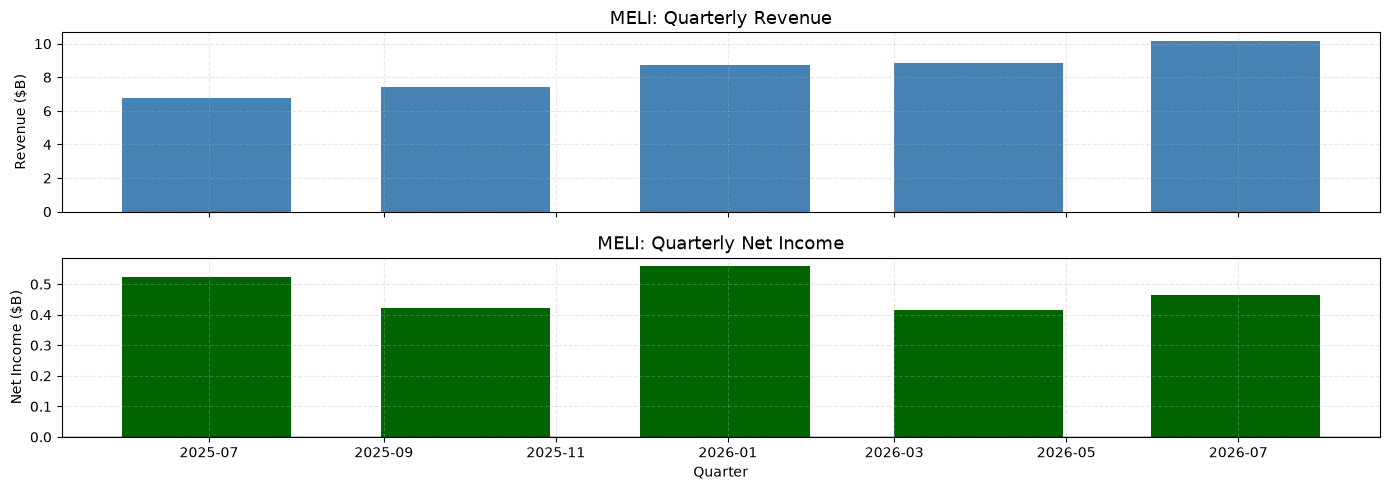

In [32]:
# ============================================================
# REVENUE & NET INCOME TIME SERIES
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].bar(
    quarterly_financials.index,
    quarterly_financials['Total Revenue'] / 1e9,
    color='steelblue',
    width=60
)
axes[0].set_title(f'{asset_ticker}: Quarterly Revenue', fontsize=13)
axes[0].set_ylabel('Revenue ($B)')
axes[0].grid(True, linestyle='--', alpha=0.3)

axes[1].bar(
    quarterly_financials.index,
    quarterly_financials['Net Income'] / 1e9,
    color='darkgreen',
    width=60
)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title(f'{asset_ticker}: Quarterly Net Income', fontsize=13)
axes[1].set_ylabel('Net Income ($B)')
axes[1].set_xlabel('Quarter')
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# YEAR-OVER-YEAR STOCK PRICE RETURNS (CALENDAR YEAR)
# ============================================================

# Resample to get the last trading price of each calendar year
annual_prices = df['Asset_Price'].resample('YE').last()

# Calculate year-over-year % return
annual_returns = annual_prices.pct_change() * 100

# Build a clean summary table
annual_returns_df = pd.DataFrame({
    'Year': annual_prices.index.year,
    'Year-End Price': annual_prices.values,
    'YoY Return (%)': annual_returns.values
})

display(annual_returns_df)

,Year,Year-End Price,YoY Return (%)
0,2017,314.660004,NaN
1,2018,292.850006,-6.931290
2,2019,571.940002,95.301346
3,2020,1675.219971,192.901347
4,2021,1348.400024,-19.509077
5,2022,846.239990,-37.241177
6,2023,1571.540039,85.708553
7,2024,1700.439941,8.202139
8,2025,2014.260010,18.455228
9,2026,1906.239990,-5.362764


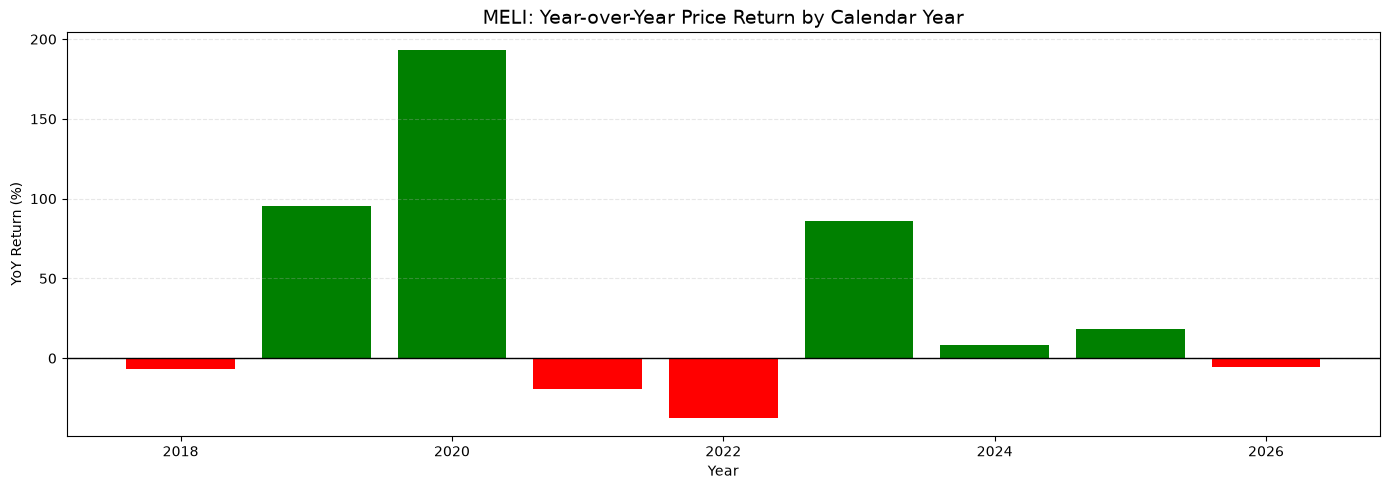

In [35]:
plt.figure(figsize=(14, 5))
colors = ['green' if x >= 0 else 'red' for x in annual_returns_df['YoY Return (%)']]

plt.bar(
    annual_returns_df['Year'],
    annual_returns_df['YoY Return (%)'],
    color=colors
)
plt.axhline(y=0, color='black', linewidth=1)
plt.title(f'{asset_ticker}: Year-over-Year Price Return by Calendar Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('YoY Return (%)')
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()